In [2]:
import h5py

path = r"C:\Users\Ahmed\Downloads\archive (1)\GOLD_XYZ_OSC.0001_1024.hdf5"
f = h5py.File(path, 'r')

for key in f.keys():
    print(key , f[key].shape, f[key].dtype)

X (2555904, 1024, 2) float32
Y (2555904, 24) int64
Z (2555904, 1) int64


In [23]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.8/350.8 MB 4.2 MB/s eta 0:01:24
   --------------------

  You can safely remove it manually.


In [3]:
print(f['X'].shape)
print(f['Y'].shape)
print(f['Z'].shape)

(2555904, 1024, 2)
(2555904, 24)
(2555904, 1)


In [5]:
import os

for root, dirs, files in os.walk(r"C:\Users\Ahmed"):
    for file in files:
        if file.endswith(".hdf5"):
            print(os.path.join(root, file))

C:\Users\Ahmed\anaconda3\Lib\site-packages\astropy\io\misc\tests\data\old_meta_example.hdf5
C:\Users\Ahmed\anaconda3\pkgs\astropy-7.0.0-py313h827c3e9_0\Lib\site-packages\astropy\io\misc\tests\data\old_meta_example.hdf5
C:\Users\Ahmed\anaconda4\Lib\site-packages\astropy\io\misc\tests\data\old_meta_example.hdf5
C:\Users\Ahmed\anaconda4\pkgs\astropy-7.0.0-py313h827c3e9_0\Lib\site-packages\astropy\io\misc\tests\data\old_meta_example.hdf5
C:\Users\Ahmed\anaconda5\Lib\site-packages\astropy\io\misc\tests\data\old_meta_example.hdf5
C:\Users\Ahmed\anaconda5\pkgs\astropy-7.0.0-py313h827c3e9_0\Lib\site-packages\astropy\io\misc\tests\data\old_meta_example.hdf5
C:\Users\Ahmed\AppData\Local\Temp\959c36f4-c596-4082-9c57-9e83bdd686a9_archive (1).zip.6a9\GOLD_XYZ_OSC.0001_1024.hdf5
C:\Users\Ahmed\AppData\Local\Temp\9b9bf834-1274-491c-8857-ed9865db2ee1_archive (1).zip.ee1\GOLD_XYZ_OSC.0001_1024.hdf5
C:\Users\Ahmed\Downloads\archive (1)\GOLD_XYZ_OSC.0001_1024.hdf5


In [6]:
f.keys()

<KeysViewHDF5 ['X', 'Y', 'Z']>

In [7]:
import numpy as np

total_samples = f['X'].shape[0]

indices = np.random.choice(
    total_samples,
    size=100000,
    replace=False
)

indices.sort()

In [8]:
X_small = f['X'][indices]
Y_small = f['Y'][indices]
Z_small = f['Z'][indices]

In [9]:
import h5py

with h5py.File("radioml_subset_100k.h5", "w") as hf:
    hf.create_dataset("X", data=X_small)
    hf.create_dataset("Y", data=Y_small)
    hf.create_dataset("Z", data=Z_small)

print("Subset saved.")

Subset saved.


In [10]:
import numpy as np

labels = np.argmax(Y_small, axis=1)

print("Number of classes:", len(np.unique(labels)))
print("Classes:", np.unique(labels))

Number of classes: 24
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [11]:
print("Min SNR:", np.min(Z_small))
print("Max SNR:", np.max(Z_small))
print("Unique SNR values:", len(np.unique(Z_small)))

Min SNR: -20
Max SNR: 30
Unique SNR values: 26


In [12]:
print("Samples:", X_small.shape[0])
print("Sequence Length:", X_small.shape[1])
print("I/Q Channels:", X_small.shape[2])
print("Modulation Classes:", Y_small.shape[1])

Samples: 100000
Sequence Length: 1024
I/Q Channels: 2
Modulation Classes: 24


In [13]:
print(f.keys())

for key in f.keys():
    print(key)
    print(f[key])
    print(f.attrs.keys())

<KeysViewHDF5 ['X', 'Y', 'Z']>
X
<HDF5 dataset "X": shape (2555904, 1024, 2), type "<f4">
<KeysViewHDF5 []>
Y
<HDF5 dataset "Y": shape (2555904, 24), type "<i8">
<KeysViewHDF5 []>
Z
<HDF5 dataset "Z": shape (2555904, 1), type "<i8">
<KeysViewHDF5 []>


In [14]:
import numpy as np

labels = np.argmax(Y_small, axis=1)

unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 0: 4194
Class 1: 4185
Class 2: 4189
Class 3: 4145
Class 4: 4205
Class 5: 4147
Class 6: 4226
Class 7: 4243
Class 8: 4153
Class 9: 4248
Class 10: 4100
Class 11: 4101
Class 12: 4227
Class 13: 4074
Class 14: 4295
Class 15: 4191
Class 16: 4093
Class 17: 4208
Class 18: 4146
Class 19: 4160
Class 20: 4133
Class 21: 4149
Class 22: 4049
Class 23: 4139


In [15]:
print(X_small.dtype)
print(Y_small.dtype)
print(Z_small.dtype)

print("\nX sample shape:")
print(X_small[0].shape)

print("\nY sample:")
print(Y_small[0])

print("\nZ sample:")
print(Z_small[0])

float32
int64
int64

X sample shape:
(1024, 2)

Y sample:
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Z sample:
[-20]


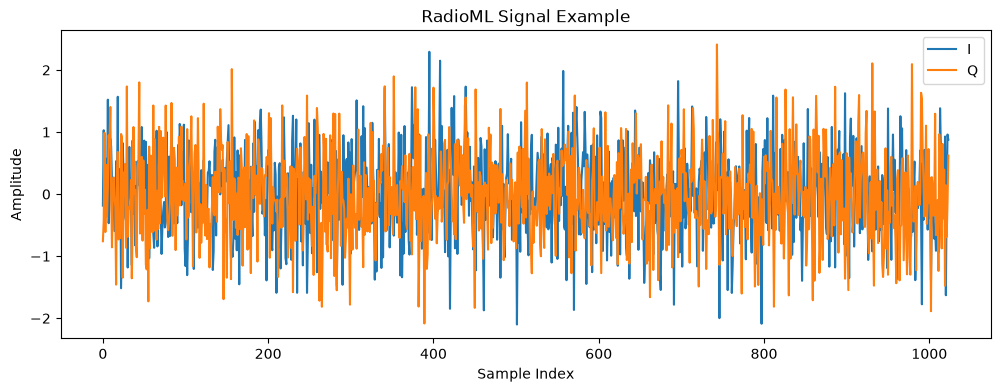

In [16]:
import matplotlib.pyplot as plt

sample = X_small[0]

I = sample[:, 0]
Q = sample[:, 1]

plt.figure(figsize=(12,4))
plt.plot(I, label='I')
plt.plot(Q, label='Q')

plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("RadioML Signal Example")
plt.legend()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp, Z_train, Z_temp = train_test_split(
    X_small, Y_small, Z_small,
    test_size=0.3,
    random_state=42,
    stratify=np.argmax(Y_small, axis=1)
)

X_val, X_test, Y_val, Y_test, Z_val, Z_test = train_test_split(
    X_temp, Y_temp, Z_temp,
    test_size=0.5,
    random_state=42,
    stratify=np.argmax(Y_temp, axis=1)
)

print(X_train.shape, X_val.shape, X_test.shape)

(70000, 1024, 2) (15000, 1024, 2) (15000, 1024, 2)


In [20]:
import numpy as np

mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

print("Normalization done")
print("Mean (train):", np.mean(X_train))
print("Std (train):", np.std(X_train))

Normalization done
Mean (train): 7.193429e-09
Std (train): 1.0


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = (1024, 2)

model = models.Sequential()

model.add(layers.Conv1D(64, 3, activation='relu', input_shape=input_shape))
model.add(layers.MaxPooling1D(2))

model.add(layers.Conv1D(128, 3, activation='relu'))
model.add(layers.MaxPooling1D(2))

model.add(layers.Conv1D(256, 3, activation='relu'))

model.add(layers.GlobalAveragePooling1D())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(24, activation='softmax'))

model.summary()

c:\Users\Ahmed\anaconda3\envs\RadioML\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1022, 64)       │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 511, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 509, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 254, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 252, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,704 (623.84 KB)

 Trainable params: 159,704 (623.84 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "baseline_cnn.h5",
        save_best_only=True
    )
]

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=20,
    batch_size=256,
    callbacks=callbacks
)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.0693 - loss: 3.0096

274/274 ━━━━━━━━━━━━━━━━━━━━ 45s 162ms/step - accuracy: 0.0959 - loss: 2.8946 - val_accuracy: 0.1715 - val_loss: 2.6765
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.1731 - loss: 2.5917

274/274 ━━━━━━━━━━━━━━━━━━━━ 125s 457ms/step - accuracy: 0.2016 - loss: 2.4575 - val_accuracy: 0.2741 - val_loss: 2.1653
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.2636 - loss: 2.1451

274/274 ━━━━━━━━━━━━━━━━━━━━ 125s 458ms/step - accuracy: 0.2766 - loss: 2.0985 - val_accuracy: 0.3141 - val_loss: 1.9613
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.2976 - loss: 2.0165

274/274 ━━━━━━━━━━━━━━━━━━━━ 43s 158ms/step - accuracy: 0.3009 - loss: 1.9994 - val_accuracy: 0.3256 - val_loss: 1.9251
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.3077 - loss: 1.9695

...

274/274 ━━━━━━━━━━━━━━━━━━━━ 111s 404ms/step - accuracy: 0.3505 - loss: 1.8323 - val_accuracy: 0.3675 - val_loss: 1.7589
Epoch 13/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 224s 815ms/step - accuracy: 0.3511 - loss: 1.8310 - val_accuracy: 0.3677 - val_loss: 1.7650
Epoch 14/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 248s 764ms/step - accuracy: 0.3575 - loss: 1.8098 - val_accuracy: 0.3659 - val_loss: 1.7709
Epoch 15/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.3600 - loss: 1.8078

274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 521ms/step - accuracy: 0.3584 - loss: 1.8043 - val_accuracy: 0.3801 - val_loss: 1.7359
Epoch 16/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 47s 173ms/step - accuracy: 0.3622 - loss: 1.7927 - val_accuracy: 0.3711 - val_loss: 1.7550
Epoch 17/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3683 - loss: 1.7846

274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 175ms/step - accuracy: 0.3683 - loss: 1.7869 - val_accuracy: 0.3846 - val_loss: 1.7214
Epoch 18/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.3705 - loss: 1.7844

274/274 ━━━━━━━━━━━━━━━━━━━━ 49s 179ms/step - accuracy: 0.3703 - loss: 1.7798 - val_accuracy: 0.3928 - val_loss: 1.7065
Epoch 19/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 49s 179ms/step - accuracy: 0.3726 - loss: 1.7700 - val_accuracy: 0.3906 - val_loss: 1.7162
Epoch 20/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.3788 - loss: 1.7506

274/274 ━━━━━━━━━━━━━━━━━━━━ 50s 181ms/step - accuracy: 0.3775 - loss: 1.7526 - val_accuracy: 0.3956 - val_loss: 1.6969
